# 01 — EDA: Explore and Validate WM-811K

This notebook validates the original MIR WM-811K dataset before any preprocessing or model-design decision is made. Wafer maps are treated as discrete spatial data—not ordinary RGB photographs—and the original arrays are never resized, padded, cropped, or deleted here.

The analysis covers dataset structure, map encoding, label availability, class imbalance, dimensions, representative patterns, map content, anomalies, the dominant `none` class, and evidence-based modeling implications. Every generated figure is saved to `output/images/`.

## 1. Setup and reproducibility

**Question.** Can the analysis locate the local dataset and write outputs independently of where Jupyter was started?

**Method.** Find the repository root, define deterministic settings, and verify the expected pickle before loading it.

In [1]:
from collections import Counter
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180, "axes.titleweight": "bold"})

In [2]:
def find_repository_root(start: Path) -> Path:
    """Return the nearest parent containing the expected WM-811K data directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "MIR-WM811K").is_dir():
            return candidate
    raise FileNotFoundError("Repository root not found. Start Jupyter from inside fdl-project.")


REPO_ROOT = find_repository_root(Path.cwd())
DATASET_PATH = REPO_ROOT / "data" / "MIR-WM811K" / "WM811K.pkl"
OUTPUT_IMAGES_DIR = REPO_ROOT / "output" / "images"
OUTPUT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. Place WM811K.pkl in data/MIR-WM811K/."
    )

print(f"Python:       {sys.version.split()[0]}")
print("Project environment: .venv")
print(f"Dataset:      {DATASET_PATH.relative_to(REPO_ROOT)}")
print(f"File size:    {DATASET_PATH.stat().st_size / 1024**3:.2f} GiB")
print(f"Image output: {OUTPUT_IMAGES_DIR.relative_to(REPO_ROOT)}")

Python:       3.12.13
Project environment: .venv
Dataset:      data\MIR-WM811K\WM811K.pkl
File size:    1.88 GiB
Image output: output\images


## 2. Load and inspect the original dataset

**Question.** What object is stored in the pickle, how large is it, and which fields are available?

**Method.** Load the complete object with pandas, then inspect its type, shape, columns, dtypes, metadata preview, and representative object-valued entries. Loading does not extract image files: every `waferMap` remains a two-dimensional array inside one DataFrame row.

In [3]:
load_started = time.perf_counter()
df = pd.read_pickle(DATASET_PATH)
load_seconds = time.perf_counter() - load_started

if not isinstance(df, pd.DataFrame):
    raise TypeError(f"Expected a pandas DataFrame, received {type(df).__name__}.")
if df.empty:
    raise ValueError("The loaded DataFrame is empty.")

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns in {load_seconds:.2f} seconds.")
print(f"Reported deep DataFrame memory: {df.memory_usage(index=True, deep=True).sum() / 1024**3:.2f} GiB")
display(df.drop(columns=["waferMap"], errors="ignore").head())
display(df.dtypes.rename("dtype").to_frame())

first_map = df["waferMap"].iloc[0]
print("First waferMap:", type(first_map).__name__, first_map.shape, first_map.dtype)
print("First failureType:", repr(df["failureType"].iloc[0]))
print("First trainTestLabel:", repr(df["trainTestLabel"].iloc[0]))

Loaded 811,457 rows and 6 columns in 28.34 seconds.


Reported deep DataFrame memory: 0.32 GiB


,dieSize,failureType,lotName,trainTestLabel,waferIndex
0,"1,683.0000",none,lot1,Training,1.0000
1,"1,683.0000",none,lot1,Training,2.0000
2,"1,683.0000",none,lot1,Training,3.0000
3,"1,683.0000",none,lot1,Training,4.0000
4,"1,683.0000",none,lot1,Training,5.0000


,dtype
dieSize,float64
failureType,object
lotName,object
trainTestLabel,object
waferIndex,float64
waferMap,object


First waferMap: ndarray (45, 48) uint8
First failureType: 'none'
First trainTestLabel: 'Training'


**Interpretation.** The schema establishes which columns are metadata and confirms that `waferMap` is object-valued because rows can contain arrays with different shapes. The reported deep-memory value does not necessarily include all memory owned by nested NumPy arrays, so available RAM should exceed this estimate.

## 3. Normalize labels without changing the source data

**Question.** How are failure labels and train/test assignments represented, and which rows are actually labeled?

**Method.** Convert scalar strings, one-element arrays, empty arrays, nulls, and blank strings to one analysis representation. The normalized series are separate objects: the original DataFrame columns remain untouched. The valid `none` value is kept as a supervised class and is not confused with a missing label.

In [4]:
def normalize_object_label(value):
    """Return a clean scalar label or pd.NA while preserving valid text such as 'none'."""
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return pd.NA
        flattened = value.reshape(-1)
        # WM-811K encodes missing labels as numeric array([0, 0]).
        if np.issubdtype(flattened.dtype, np.number) and np.all(flattened == 0):
            return pd.NA
        value = flattened[0]
    if value is None:
        return pd.NA
    try:
        if pd.isna(value):
            return pd.NA
    except (TypeError, ValueError):
        pass
    text = str(value).strip()
    return text if text else pd.NA


failure_label = df["failureType"].map(normalize_object_label).astype("string")
split_label = df["trainTestLabel"].map(normalize_object_label).astype("string")
is_labeled = failure_label.notna()

label_availability = pd.DataFrame(
    {"count": [int(is_labeled.sum()), int((~is_labeled).sum())]},
    index=["Labeled", "Unlabeled"],
)
label_availability["percentage"] = 100 * label_availability["count"] / len(df)
display(label_availability)

print("Original failureType Python types:", df["failureType"].map(type).map(lambda x: x.__name__).value_counts().to_dict())
print("Normalized failure labels:", sorted(failure_label.dropna().unique().tolist()))
print("Normalized train/test values:", split_label.value_counts(dropna=False).to_dict())

,count,percentage
Labeled,172950,21.3135
Unlabeled,638507,78.6865


Original failureType Python types: {'ndarray': 638507, 'str': 172950}
Normalized failure labels: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


Normalized train/test values: {<NA>: 638507, 'Test': 118595, 'Training': 54355}


## 4. Validate every wafer map and its discrete encoding

**Question.** Are all maps numeric, two-dimensional, non-empty, and encoded only with the expected categorical values? What are their dimensions and die-level contents?

**Method.** Scan every map once. For each row, record height, width, background/good/defective counts, active-die count, defective-die ratio, occupancy ratio, and malformed-map flags. Encoding is inferred from all cells rather than assumed from a single example. No row is removed or repaired.

In [5]:
def profile_wafer_maps(wafer_maps):
    n_maps = len(wafer_maps)
    profile = {
        "height": np.full(n_maps, -1, dtype=np.int32),
        "width": np.full(n_maps, -1, dtype=np.int32),
        "n_background": np.full(n_maps, -1, dtype=np.int32),
        "n_good": np.full(n_maps, -1, dtype=np.int32),
        "n_defective": np.full(n_maps, -1, dtype=np.int32),
        "n_active": np.full(n_maps, -1, dtype=np.int32),
        "bad_ratio": np.full(n_maps, np.nan, dtype=np.float32),
        "occupancy_ratio": np.full(n_maps, np.nan, dtype=np.float32),
        "is_2d": np.zeros(n_maps, dtype=bool),
        "is_empty": np.zeros(n_maps, dtype=bool),
        "is_numeric": np.zeros(n_maps, dtype=bool),
        "has_nan": np.zeros(n_maps, dtype=bool),
        "has_inf": np.zeros(n_maps, dtype=bool),
        "has_unexpected_value": np.zeros(n_maps, dtype=bool),
    }
    encoding_cell_counts = Counter()
    dtype_counts = Counter()

    for position, wafer in enumerate(wafer_maps):
        try:
            array = np.asarray(wafer)
        except Exception:
            continue

        dtype_counts[str(array.dtype)] += 1
        if array.ndim != 2:
            continue
        profile["is_2d"][position] = True
        profile["height"][position], profile["width"][position] = array.shape
        if array.size == 0:
            profile["is_empty"][position] = True
            continue
        if not np.issubdtype(array.dtype, np.number):
            continue
        profile["is_numeric"][position] = True

        if np.issubdtype(array.dtype, np.inexact):
            profile["has_nan"][position] = bool(np.isnan(array).any())
            profile["has_inf"][position] = bool(np.isinf(array).any())

        n_background = int(np.count_nonzero(array == 0))
        n_good = int(np.count_nonzero(array == 1))
        n_defective = int(np.count_nonzero(array == 2))
        n_expected = n_background + n_good + n_defective
        n_active = n_good + n_defective

        profile["n_background"][position] = n_background
        profile["n_good"][position] = n_good
        profile["n_defective"][position] = n_defective
        profile["n_active"][position] = n_active
        profile["has_unexpected_value"][position] = n_expected != array.size
        profile["bad_ratio"][position] = n_defective / n_active if n_active else np.nan
        profile["occupancy_ratio"][position] = n_active / array.size

        encoding_cell_counts[0] += n_background
        encoding_cell_counts[1] += n_good
        encoding_cell_counts[2] += n_defective
        encoding_cell_counts["unexpected"] += array.size - n_expected

    return pd.DataFrame(profile, index=df.index), encoding_cell_counts, dtype_counts


scan_started = time.perf_counter()
map_profile, encoding_cell_counts, map_dtype_counts = profile_wafer_maps(df["waferMap"].to_numpy())
scan_seconds = time.perf_counter() - scan_started
map_profile["aspect_ratio"] = map_profile["width"] / map_profile["height"].replace(-1, np.nan)

encoding_summary = pd.DataFrame(
    {
        "meaning": ["background / no die", "functional die", "defective die", "unexpected"],
        "cell_count": [encoding_cell_counts[0], encoding_cell_counts[1], encoding_cell_counts[2], encoding_cell_counts["unexpected"]],
    },
    index=[0, 1, 2, "other"],
)
encoding_summary["percentage"] = 100 * encoding_summary["cell_count"] / encoding_summary["cell_count"].sum()

print(f"Scanned all {len(map_profile):,} maps in {scan_seconds:.2f} seconds.")
print("Map dtypes:", dict(map_dtype_counts))
display(encoding_summary)

Scanned all 811,457 maps in 66.40 seconds.
Map dtypes: {'uint8': 811457}


,meaning,cell_count,percentage
0,background / no die,422404108,22.0427
1,functional die,1393453681,72.7160
2,defective die,100437508,5.2412
other,unexpected,0,0.0000


In [6]:
structural_validation = pd.Series(
    {
        "non_2d_maps": int((~map_profile["is_2d"]).sum()),
        "empty_maps": int(map_profile["is_empty"].sum()),
        "non_numeric_maps": int((map_profile["is_2d"] & ~map_profile["is_numeric"]).sum()),
        "maps_with_nan": int(map_profile["has_nan"].sum()),
        "maps_with_infinity": int(map_profile["has_inf"].sum()),
        "maps_with_unexpected_codes": int(map_profile["has_unexpected_value"].sum()),
        "maps_without_active_dies": int((map_profile["n_active"] == 0).sum()),
    },
    name="count",
)
display(structural_validation.to_frame())

if encoding_cell_counts["unexpected"] == 0:
    print("Result: across all valid numeric maps, the observed encoding is exactly {0, 1, 2}.")
    print("Interpretation: 0 = background, 1 = functional die, and 2 = defective die, consistent with the dataset documentation.")
else:
    print("Result: unexpected cell values exist and require row-level investigation before preprocessing.")

,count
non_2d_maps,0
empty_maps,0
non_numeric_maps,0
maps_with_nan,0
maps_with_infinity,0
maps_with_unexpected_codes,0
maps_without_active_dies,0


Result: across all valid numeric maps, the observed encoding is exactly {0, 1, 2}.
Interpretation: 0 = background, 1 = functional die, and 2 = defective die, consistent with the dataset documentation.


## 5. Labeled versus unlabeled observations and class imbalance

**Question.** How much of the dataset is usable for supervised classification, and how imbalanced are the labeled classes?

**Method.** Count normalized labels, calculate within-labeled percentages, and compare the largest and smallest classes. Unlabeled rows are excluded from supervised class frequencies. Bar charts start at zero and use direct value labels.

In [7]:
class_counts = failure_label[is_labeled].value_counts().sort_values(ascending=False)
class_table = class_counts.rename("count").to_frame()
class_table["percentage_of_labeled"] = 100 * class_table["count"] / class_table["count"].sum()
display(class_table)

rarest_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Majority class: {majority_class!r} ({class_counts.max():,} maps)")
print(f"Rarest class:   {rarest_class!r} ({class_counts.min():,} maps)")
print(f"Majority/minority ratio: {imbalance_ratio:,.1f}:1")

,count,percentage_of_labeled
failureType,,
none,147431,85.2449
Edge-Ring,9680,5.5970
Edge-Loc,5189,3.0003
Center,4294,2.4828
Loc,3593,2.0775
Scratch,1193,0.6898
Random,866,0.5007
Donut,555,0.3209
Near-full,149,0.0862


Majority class: 'none' (147,431 maps)
Rarest class:   'Near-full' (149 maps)
Majority/minority ratio: 989.5:1


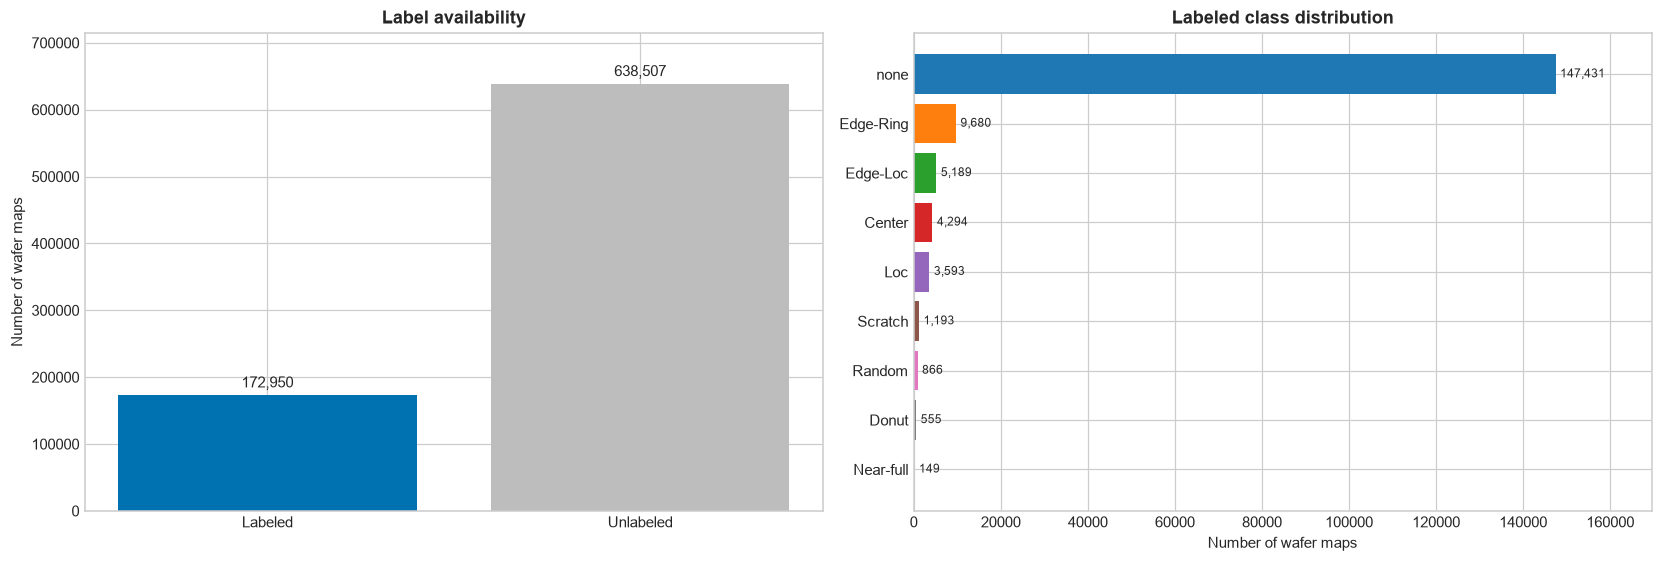

Saved: output\images\class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

availability_colors = ["#0072B2", "#BDBDBD"]
bars = axes[0].bar(label_availability.index, label_availability["count"], color=availability_colors)
axes[0].bar_label(bars, labels=[f"{value:,.0f}" for value in label_availability["count"]], padding=3)
axes[0].set(title="Label availability", ylabel="Number of wafer maps")
axes[0].set_ylim(0, label_availability["count"].max() * 1.12)

plot_counts = class_counts.sort_values()
class_palette = dict(zip(class_counts.index, plt.get_cmap("tab10").colors[: len(class_counts)]))
bars = axes[1].barh(plot_counts.index, plot_counts.values, color=[class_palette[name] for name in plot_counts.index])
axes[1].bar_label(bars, labels=[f"{value:,}" for value in plot_counts.values], padding=3, fontsize=8)
axes[1].set(title="Labeled class distribution", xlabel="Number of wafer maps")
axes[1].set_xlim(0, plot_counts.max() * 1.15)

figure_path = OUTPUT_IMAGES_DIR / "class_distribution.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

**Modeling implication.** A purely supervised baseline must train only on labeled rows. Overall accuracy will be misleading under strong imbalance; macro-F1, per-class recall/F1, and the confusion matrix should accompany it. Weighted loss, balanced sampling, and augmentation are candidates to test later—not conclusions selected by this EDA alone.

## 6. Wafer-map dimensions and shapes

**Question.** Can maps be batched directly, or do their spatial dimensions vary? Which shapes are common and which are unusual?

**Method.** Summarize height, width, area, and aspect ratio for every valid 2D map; count exact `(height, width)` pairs; and visualize distributions. Histogram axes are limited to the 99.5th percentile for readability, while full minima/maxima remain in the table and unusual extremes are inspected separately.

In [9]:
valid_2d = map_profile["is_2d"] & ~map_profile["is_empty"]
dimensions = map_profile.loc[valid_2d, ["height", "width", "aspect_ratio"]].copy()
dimensions["area"] = dimensions["height"] * dimensions["width"]
dimension_summary = dimensions[["height", "width", "area", "aspect_ratio"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
display(dimension_summary)

shape_counts = dimensions.groupby(["height", "width"]).size().sort_values(ascending=False)
shape_table = shape_counts.head(15).rename("count").to_frame()
shape_table["percentage"] = 100 * shape_table["count"] / len(dimensions)
display(shape_table)
print(f"Unique map shapes: {len(shape_counts):,}")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
height,"811,457.0000",45.0596,25.4852,6.0000,22.0000,25.0000,31.0000,36.0000,51.0000,88.0000,137.0000,300.0000
width,"811,457.0000",43.1202,21.3905,3.0000,25.0000,26.0000,29.0000,35.0000,50.0000,83.0000,131.0000,205.0000
area,"811,457.0000","2,361.5488","2,856.6928",45.0000,650.0000,675.0000,928.0000,"1,260.0000","2,500.0000","7,128.0000","17,808.0000","60,600.0000"
aspect_ratio,"811,457.0000",0.9927,0.4264,0.2000,0.5038,0.7931,0.9062,0.9859,1.0800,1.1569,1.8214,15.0000


count  percentage
height width                    
32     29     108687     13.3941
25     27      64083      7.8973
49     39      39323      4.8460
26     26      30078      3.7067
30     34      29513      3.6370
33     33      23886      2.9436
       29      20276      2.4987
39     37      15327      1.8888
52     59      14812      1.8254
31     31      14569      1.7954
39     31      13562      1.6713
29     26      13247      1.6325
27     25      12655      1.5595
64     71      11692      1.4409
31     28      10788      1.3295

Unique map shapes: 632


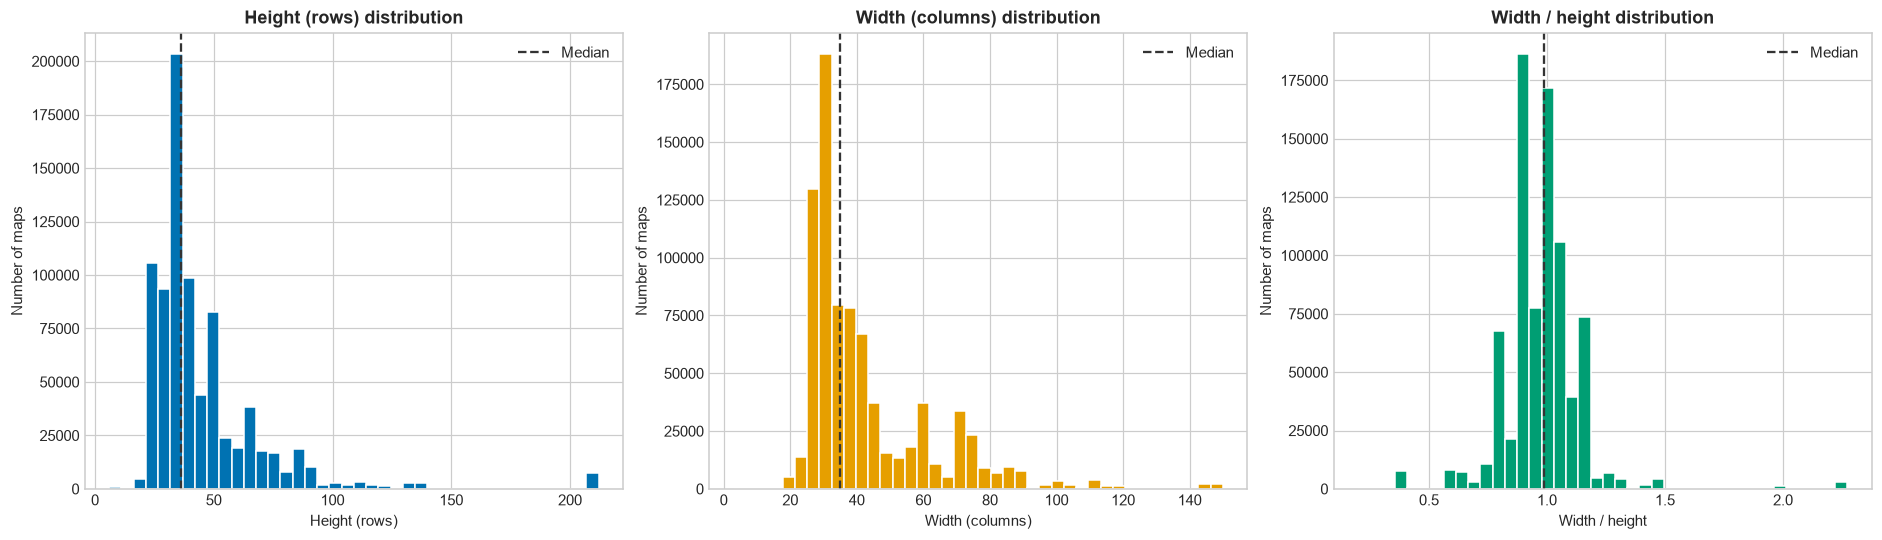

Saved: output\images\wafer_dimension_distributions.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)
dimension_specs = [("height", "Height (rows)", "#0072B2"), ("width", "Width (columns)", "#E69F00"), ("aspect_ratio", "Width / height", "#009E73")]
for axis, (column, label, color) in zip(axes, dimension_specs):
    upper = dimensions[column].quantile(0.995)
    shown = dimensions.loc[dimensions[column] <= upper, column]
    axis.hist(shown, bins=40, color=color, edgecolor="white")
    axis.axvline(dimensions[column].median(), color="#333333", linestyle="--", label="Median")
    axis.set(title=f"{label} distribution", xlabel=label, ylabel="Number of maps")
    axis.legend()

figure_path = OUTPUT_IMAGES_DIR / "wafer_dimension_distributions.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

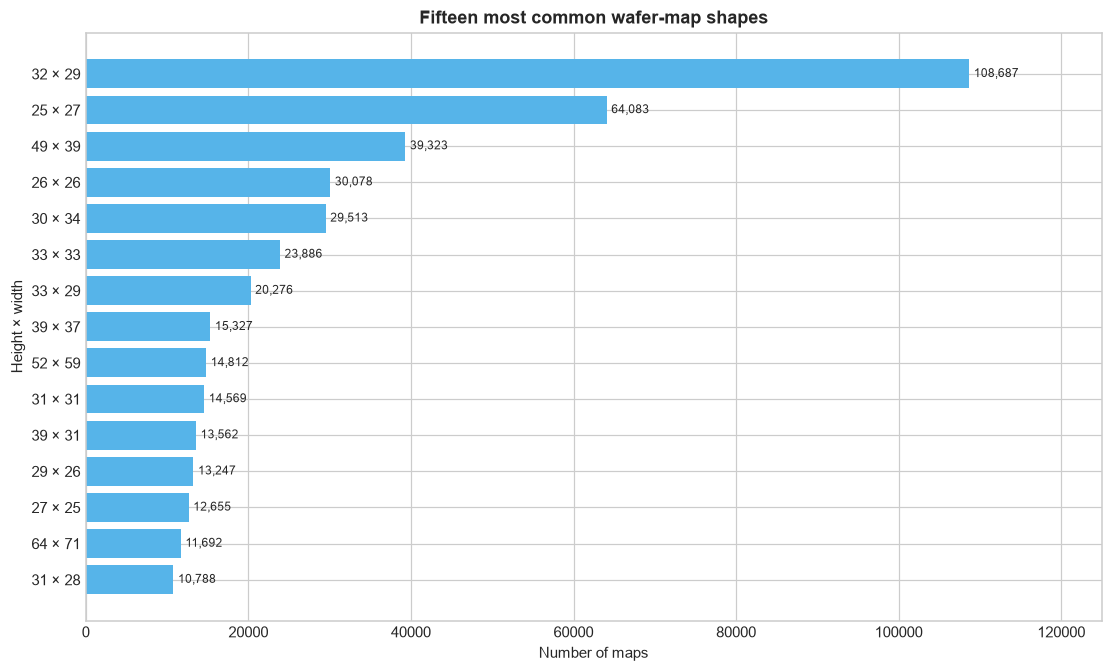

Saved: output\images\most_common_wafer_shapes.png


In [11]:
top_shapes = shape_counts.head(15).sort_values()
shape_names = [f"{height} × {width}" for height, width in top_shapes.index]
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
bars = ax.barh(shape_names, top_shapes.values, color="#56B4E9")
ax.bar_label(bars, labels=[f"{value:,}" for value in top_shapes.values], padding=3, fontsize=8)
ax.set(title="Fifteen most common wafer-map shapes", xlabel="Number of maps", ylabel="Height × width")
ax.set_xlim(0, top_shapes.max() * 1.15)
figure_path = OUTPUT_IMAGES_DIR / "most_common_wafer_shapes.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

**Modeling implication.** If multiple dimensions are observed, a fixed-size representation is required before PyTorch can form ordinary dense batches. Padding and categorical-preserving resizing should be compared later. Interpolation must not invent invalid values between the discrete codes 0, 1, and 2.

## 7. Representative labeled wafers

**Question.** What spatial patterns and within-class variability are visible in each labeled class?

**Method.** For each class, select three deterministic examples nearest its 25th, 50th, and 75th defective-die-ratio quantiles. A discrete colorblind-safe encoding is used consistently: light gray = background, blue = functional die, orange = defective die. Selection by quantiles avoids presenting only the first or most visually convenient sample.

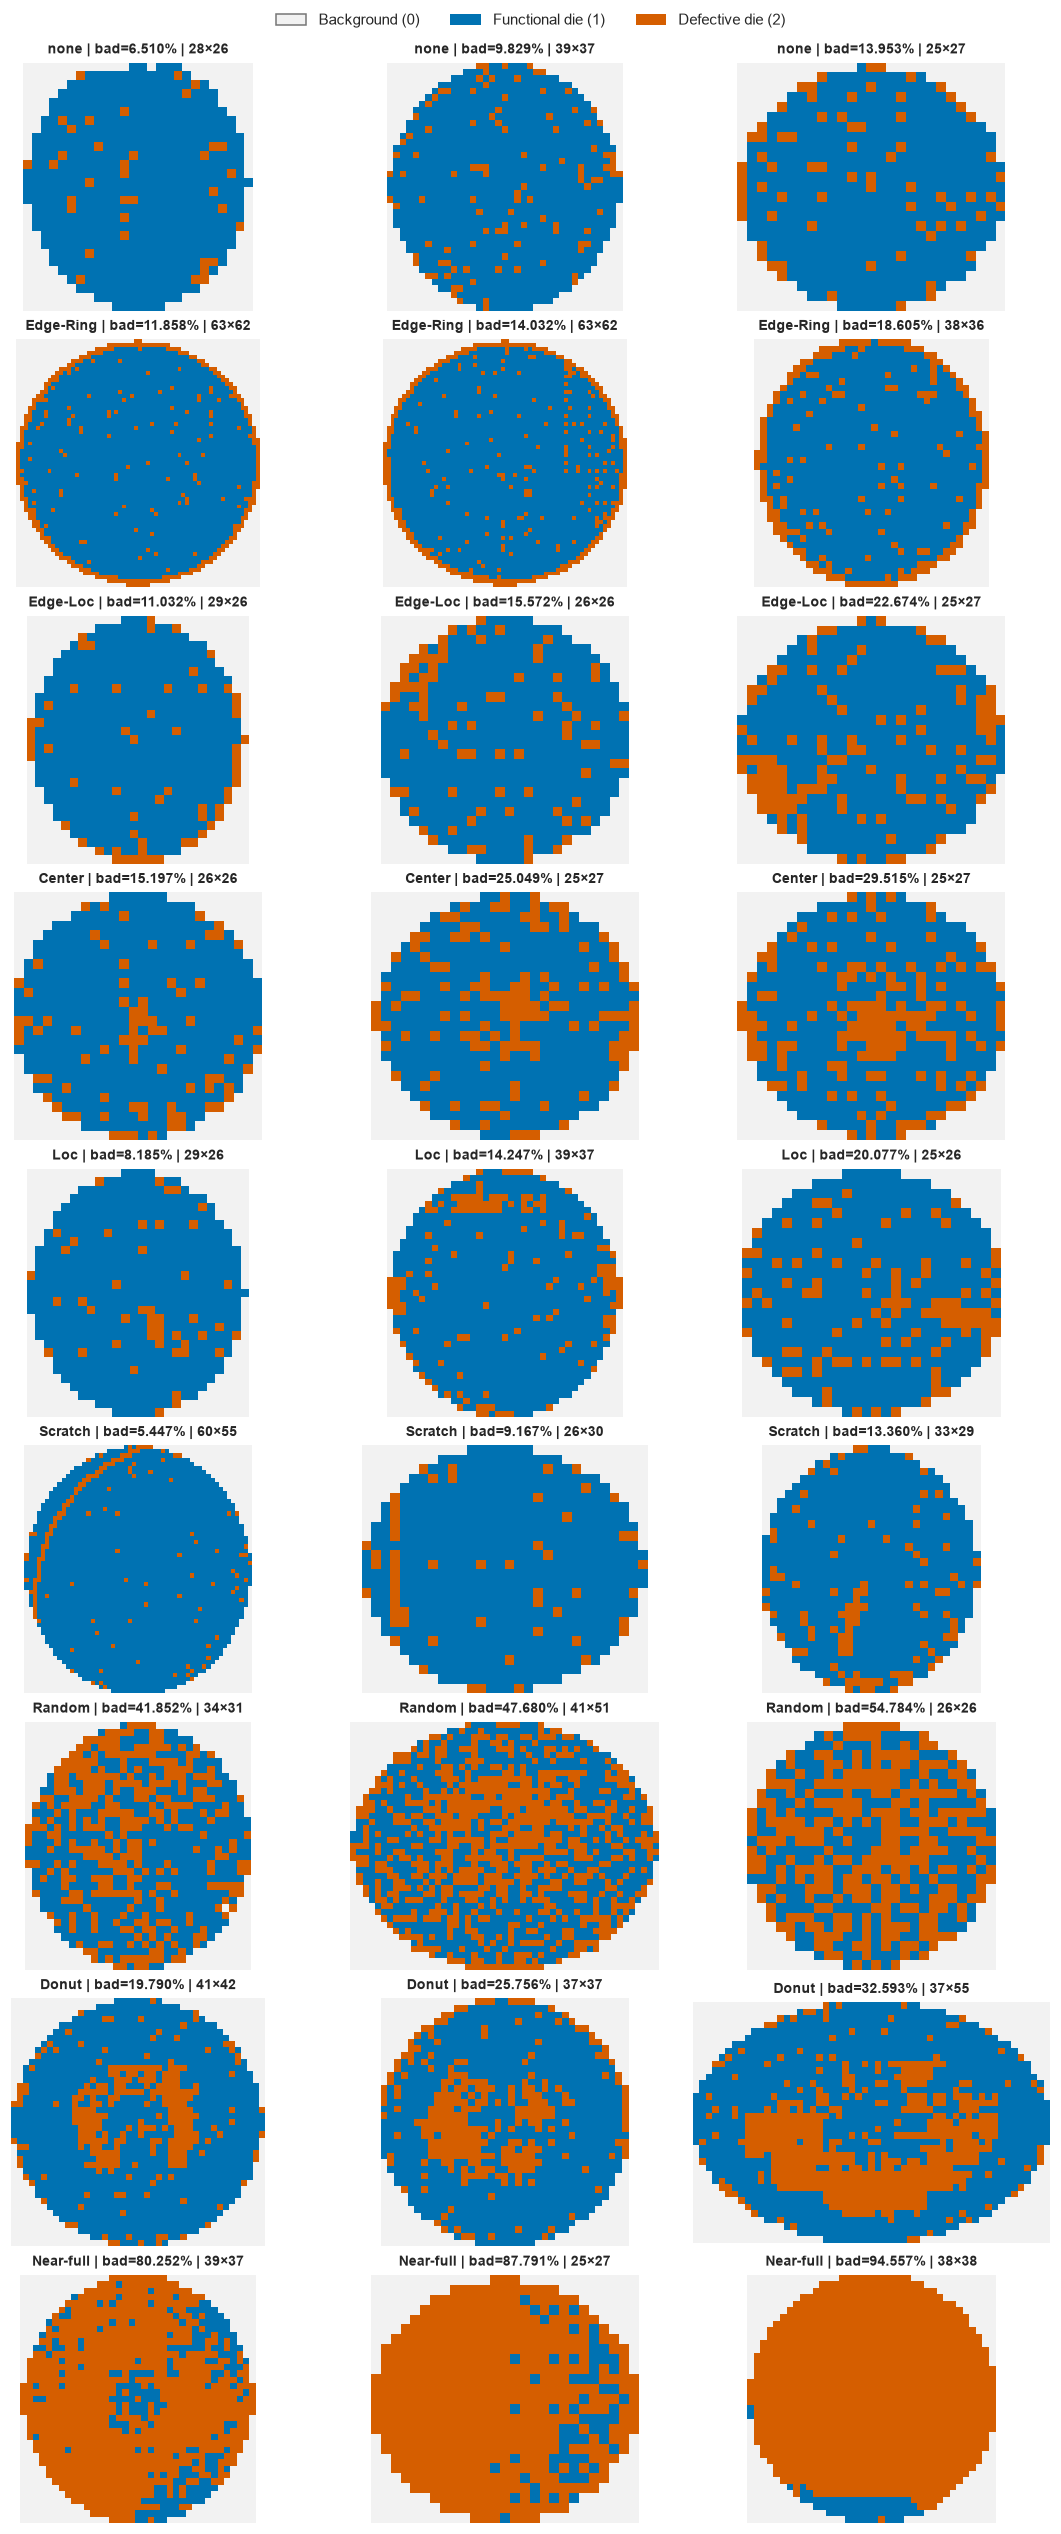

Saved: output\images\representative_wafers_by_class.png


In [12]:
WAFER_CMAP = ListedColormap(["#F2F2F2", "#0072B2", "#D55E00"])
WAFER_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], WAFER_CMAP.N)
WAFER_LEGEND = [
    Patch(facecolor="#F2F2F2", edgecolor="#777777", label="Background (0)"),
    Patch(facecolor="#0072B2", label="Functional die (1)"),
    Patch(facecolor="#D55E00", label="Defective die (2)"),
]


def quantile_example_indices(indices, values, quantiles=(0.25, 0.50, 0.75)):
    available = pd.Series(values.loc[indices]).dropna()
    if available.empty:
        return list(indices[: len(quantiles)])
    selected = []
    for quantile in quantiles:
        target = available.quantile(quantile)
        ordered = (available - target).abs().sort_values().index
        chosen = next((index for index in ordered if index not in selected), ordered[0])
        selected.append(chosen)
    return selected


class_order = class_counts.index.tolist()
examples_by_class = {}
for class_name in class_order:
    indices = failure_label.index[failure_label.eq(class_name)]
    examples_by_class[class_name] = quantile_example_indices(indices, map_profile["bad_ratio"])
fig, axes = plt.subplots(len(class_order), 3, figsize=(10, 2.55 * len(class_order)), constrained_layout=True)
for row, class_name in enumerate(class_order):
    for column, index in enumerate(examples_by_class[class_name]):
        axis = axes[row, column]
        axis.imshow(df.at[index, "waferMap"], cmap=WAFER_CMAP, norm=WAFER_NORM, interpolation="nearest")
        ratio = map_profile.at[index, "bad_ratio"]
        axis.set_title(f"{class_name} | bad={ratio:.3%} | {map_profile.at[index, 'height']}×{map_profile.at[index, 'width']}", fontsize=9)
        axis.set_axis_off()
fig.legend(handles=WAFER_LEGEND, loc="outside upper center", ncol=3, frameon=False)
figure_path = OUTPUT_IMAGES_DIR / "representative_wafers_by_class.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

## 8. Defect density by class

**Question.** Do classes differ only spatially, or also in the proportion of defective dies?

**Method.** Compare `n_defective / n_active` across labeled classes using distribution summaries and box plots. Outliers remain part of the analysis; they are not automatically errors.

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Scratch,"1,193.0000",0.1006,0.0608,0.0071,0.0545,0.0917,0.1336,0.3930
none,"147,431.0000",0.1056,0.0531,0.0000,0.0651,0.0983,0.1395,0.4706
Edge-Ring,"9,680.0000",0.1513,0.0530,0.0169,0.1186,0.1403,0.1860,0.4510
Loc,"3,593.0000",0.1500,0.0972,0.0052,0.0819,0.1425,0.2008,0.6976
Edge-Loc,"5,189.0000",0.1828,0.1087,0.0109,0.1103,0.1557,0.2267,0.7461
Center,"4,294.0000",0.2325,0.1029,0.0090,0.1520,0.2505,0.2951,0.7271
Donut,555.0000,0.2768,0.1116,0.0536,0.1983,0.2576,0.3257,0.6784
Random,866.0000,0.4806,0.1083,0.1582,0.4186,0.4768,0.5478,0.7705
Near-full,149.0000,0.8769,0.0835,0.7223,0.8025,0.8779,0.9456,1.0000


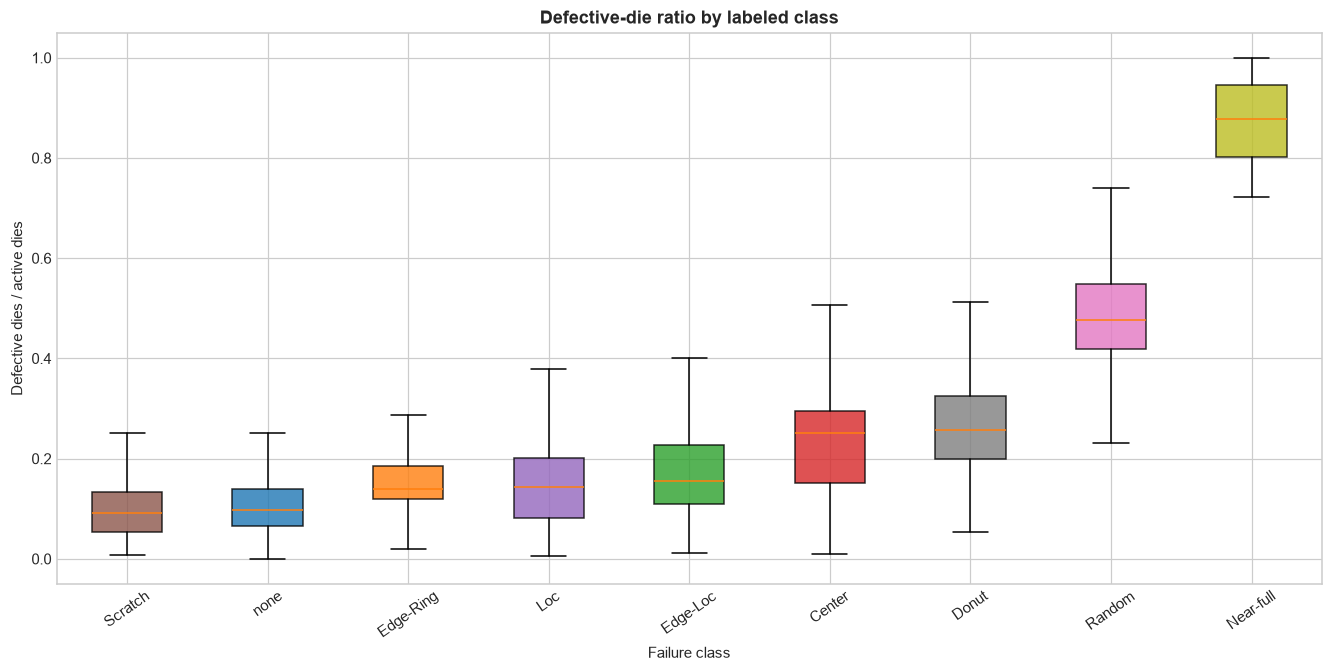

Saved: output\images\defective_die_ratio_by_class.png


In [13]:
labeled_content = pd.DataFrame({"class": failure_label[is_labeled], "bad_ratio": map_profile.loc[is_labeled, "bad_ratio"]})
bad_ratio_summary = labeled_content.groupby("class")["bad_ratio"].describe(percentiles=[0.25, 0.5, 0.75])
display(bad_ratio_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].sort_values("50%"))

box_order = bad_ratio_summary["50%"].sort_values().index.tolist()
box_data = [labeled_content.loc[labeled_content["class"].eq(name), "bad_ratio"].dropna().to_numpy() for name in box_order]
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
box = ax.boxplot(box_data, tick_labels=box_order, patch_artist=True, showfliers=False)
for patch, class_name in zip(box["boxes"], box_order):
    patch.set_facecolor(class_palette[class_name])
    patch.set_alpha(0.8)
ax.set(title="Defective-die ratio by labeled class", xlabel="Failure class", ylabel="Defective dies / active dies")
ax.tick_params(axis="x", rotation=35)
figure_path = OUTPUT_IMAGES_DIR / "defective_die_ratio_by_class.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

**Interpretation.** Differences in defect density may help classification, but spatial geometry remains essential: classes can overlap in defective-die ratio while representing distinct patterns. A model should therefore preserve spatial structure rather than rely only on aggregate counts.

## 9. Malformed and unusual maps

**Question.** Which observations are structurally invalid, inconsistent with metadata, or extreme enough to require review?

**Method.** Report malformed conditions separately from unusual-but-valid dimensions. Compare `dieSize` with the active-die count derived from each map, check duplicate `(lotName, waferIndex)` identifiers, and flag the outer 0.5% dimension tails for visual inspection. Flags describe evidence; they do not trigger automatic deletion.

,count
unusual_dimension_tail_maps,4755
non_2d_maps,0
empty_maps,0
non_numeric_maps,0
maps_with_infinity,0
maps_with_nan,0
maps_with_unexpected_codes,0
maps_without_active_dies,0
dieSize_active_count_mismatch,0
rows_with_duplicate_lot_wafer_id,0


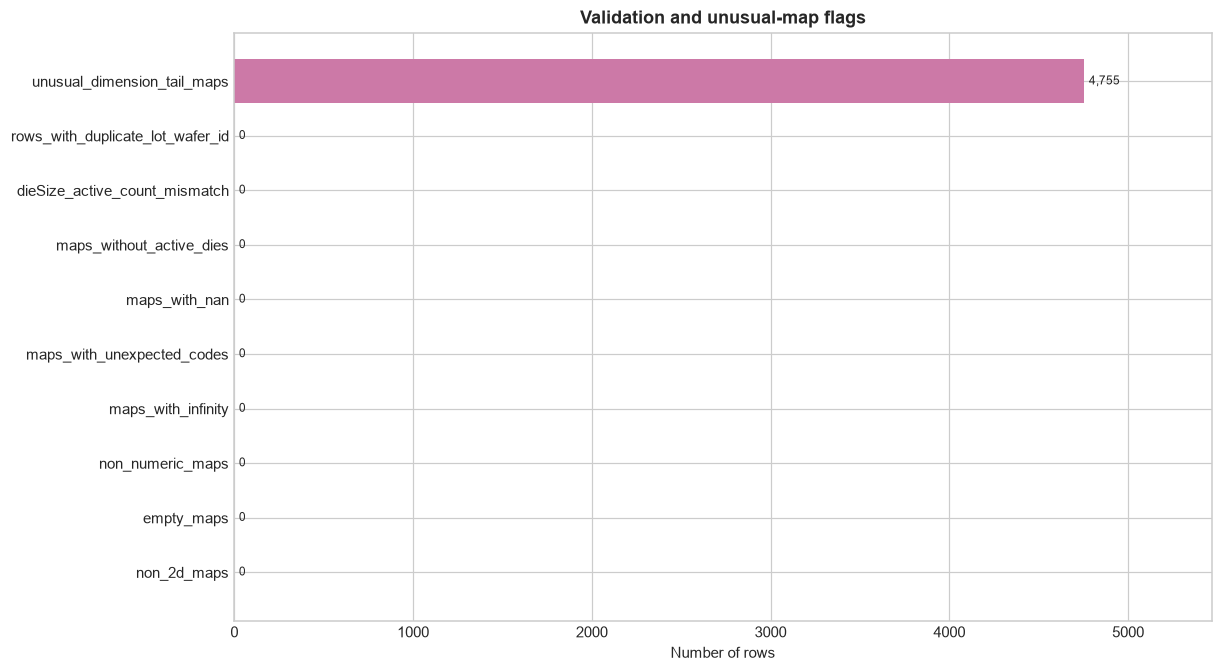

Saved: output\images\wafer_validation_flags.png


In [14]:
die_size = pd.to_numeric(df["dieSize"], errors="coerce")
die_size_mismatch = die_size.notna() & map_profile["n_active"].ge(0) & ~np.isclose(die_size, map_profile["n_active"])
duplicate_identifiers = df.duplicated(subset=["lotName", "waferIndex"], keep=False)

height_low, height_high = dimensions["height"].quantile([0.005, 0.995])
width_low, width_high = dimensions["width"].quantile([0.005, 0.995])
unusual_dimensions = valid_2d & (
    map_profile["height"].lt(height_low)
    | map_profile["height"].gt(height_high)
    | map_profile["width"].lt(width_low)
    | map_profile["width"].gt(width_high)
)

anomaly_summary = pd.Series(
    {
        **structural_validation.to_dict(),
        "dieSize_active_count_mismatch": int(die_size_mismatch.sum()),
        "rows_with_duplicate_lot_wafer_id": int(duplicate_identifiers.sum()),
        "unusual_dimension_tail_maps": int(unusual_dimensions.sum()),
    },
    name="count",
).sort_values(ascending=False)
display(anomaly_summary.to_frame())

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
plot_anomalies = anomaly_summary.sort_values()
bars = ax.barh(plot_anomalies.index, plot_anomalies.values, color="#CC79A7")
ax.bar_label(bars, labels=[f"{value:,}" for value in plot_anomalies.values], padding=3, fontsize=8)
ax.set(title="Validation and unusual-map flags", xlabel="Number of rows")
ax.set_xlim(0, max(plot_anomalies.max() * 1.15, 1))
figure_path = OUTPUT_IMAGES_DIR / "wafer_validation_flags.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

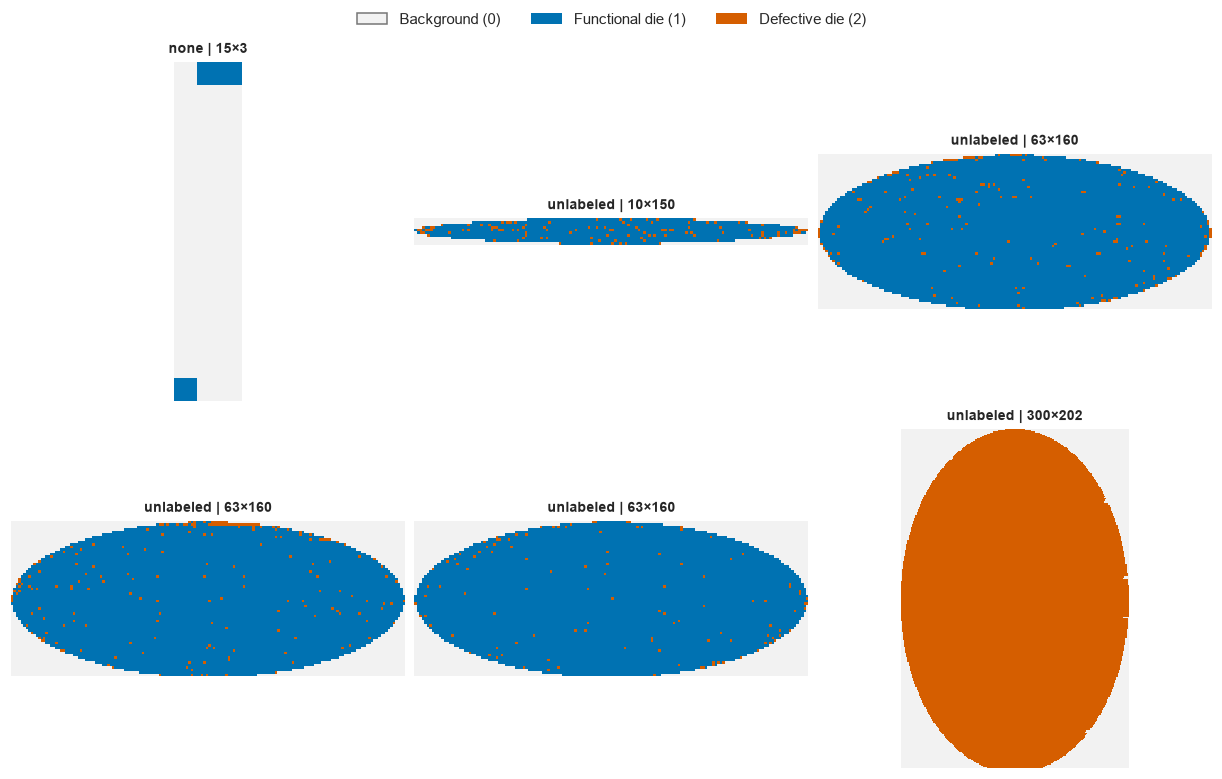

Saved: output\images\unusual_dimension_examples.png


In [15]:
unusual_indices = map_profile.index[unusual_dimensions]
if len(unusual_indices):
    ordered_unusual = map_profile.loc[unusual_indices].assign(area=lambda x: x["height"] * x["width"]).sort_values("area")
    example_positions = np.linspace(0, len(ordered_unusual) - 1, min(6, len(ordered_unusual)), dtype=int)
    selected_unusual = ordered_unusual.iloc[example_positions].index
    fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
    for axis, index in zip(axes.flat, selected_unusual):
        axis.imshow(df.at[index, "waferMap"], cmap=WAFER_CMAP, norm=WAFER_NORM, interpolation="nearest")
        label = failure_label.at[index] if pd.notna(failure_label.at[index]) else "unlabeled"
        axis.set_title(f"{label} | {map_profile.at[index, 'height']}×{map_profile.at[index, 'width']}", fontsize=9)
        axis.set_axis_off()
    for axis in axes.flat[len(selected_unusual):]:
        axis.set_visible(False)
    fig.legend(handles=WAFER_LEGEND, loc="outside upper center", ncol=3, frameon=False)
    figure_path = OUTPUT_IMAGES_DIR / "unusual_dimension_examples.png"
    fig.savefig(figure_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")
else:
    print("No maps fall outside the dimension-tail thresholds.")

## 10. Dedicated analysis of the `none` class

**Question.** Does `none` mean that a wafer contains no defective dies, or that it has no recognized spatial failure pattern? How heterogeneous is this class?

**Method.** Compare its size and defective-die ratios with all named failure classes, count `none` maps that still contain defective dies, and visualize deterministic low/median/high-ratio examples.

,value
none_maps,"147,431.0000"
percentage_of_labeled,85.2449
none_maps_with_defective_dies,"147,430.0000"
percentage_none_with_defective_dies,99.9993
none_median_bad_ratio,0.0983
named_failure_median_bad_ratio,0.1588


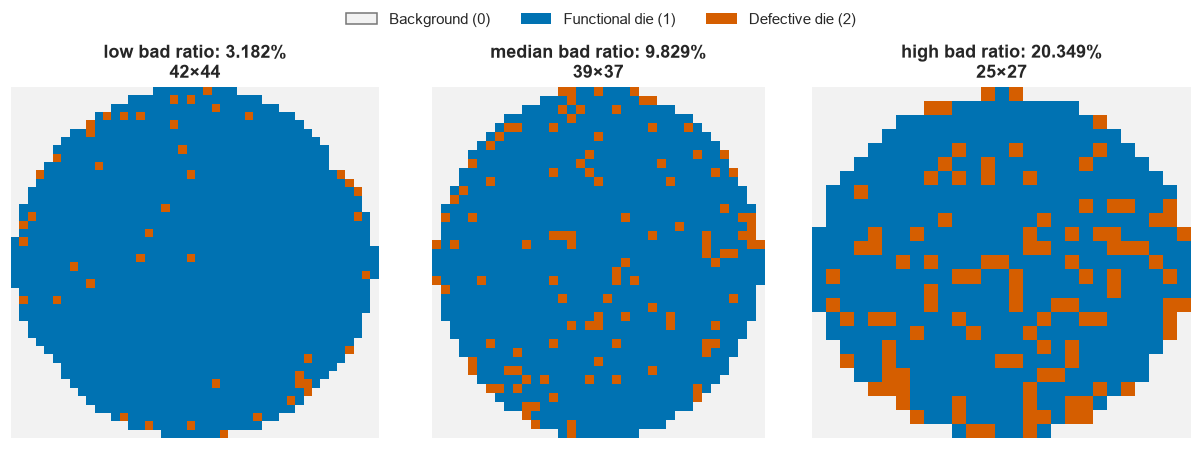

Saved: output\images\none_class_examples.png


In [16]:
none_label_candidates = [name for name in class_counts.index if name.casefold() == "none"]
if len(none_label_candidates) != 1:
    raise ValueError(f"Expected one normalized none class, found {none_label_candidates}.")
none_label = none_label_candidates[0]
is_none = failure_label.eq(none_label).fillna(False)
is_named_failure = is_labeled & ~is_none

none_summary = pd.Series(
    {
        "none_maps": int(is_none.sum()),
        "percentage_of_labeled": 100 * is_none.sum() / is_labeled.sum(),
        "none_maps_with_defective_dies": int((is_none & map_profile["n_defective"].gt(0)).sum()),
        "percentage_none_with_defective_dies": 100 * (is_none & map_profile["n_defective"].gt(0)).sum() / is_none.sum(),
        "none_median_bad_ratio": map_profile.loc[is_none, "bad_ratio"].median(),
        "named_failure_median_bad_ratio": map_profile.loc[is_named_failure, "bad_ratio"].median(),
    },
    name="value",
)
display(none_summary.to_frame())

none_indices = failure_label.index[is_none]
none_examples = quantile_example_indices(none_indices, map_profile["bad_ratio"], quantiles=(0.05, 0.50, 0.95))
fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for axis, index, quantile in zip(axes, none_examples, ("low", "median", "high")):
    axis.imshow(df.at[index, "waferMap"], cmap=WAFER_CMAP, norm=WAFER_NORM, interpolation="nearest")
    axis.set_title(f"{quantile} bad ratio: {map_profile.at[index, 'bad_ratio']:.3%}\n{map_profile.at[index, 'height']}×{map_profile.at[index, 'width']}")
    axis.set_axis_off()
fig.legend(handles=WAFER_LEGEND, loc="outside upper center", ncol=3, frameon=False)
figure_path = OUTPUT_IMAGES_DIR / "none_class_examples.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

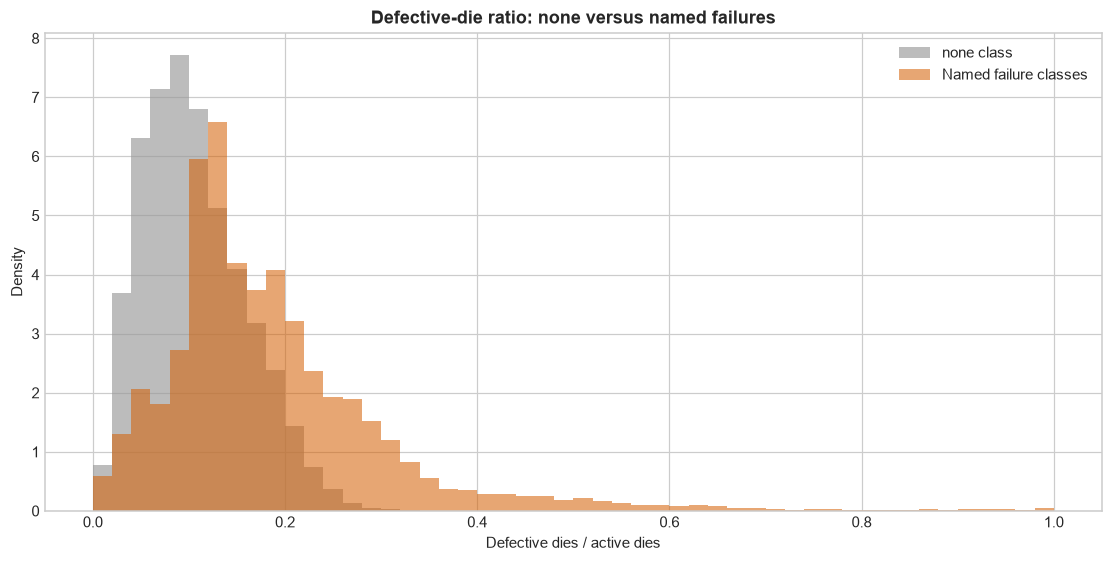

Saved: output\images\none_vs_failure_bad_ratio.png
Interpretation: 'none' does not mean zero defective dies; it denotes no recognized failure-pattern label.


In [17]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bins = np.linspace(0, 1, 51)
ax.hist(map_profile.loc[is_none, "bad_ratio"].dropna(), bins=bins, density=True, alpha=0.65, color="#999999", label=f"{none_label} class")
ax.hist(map_profile.loc[is_named_failure, "bad_ratio"].dropna(), bins=bins, density=True, alpha=0.55, color="#D55E00", label="Named failure classes")
ax.set(title="Defective-die ratio: none versus named failures", xlabel="Defective dies / active dies", ylabel="Density")
ax.legend()
figure_path = OUTPUT_IMAGES_DIR / "none_vs_failure_bad_ratio.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path.relative_to(REPO_ROOT)}")

if none_summary["none_maps_with_defective_dies"] > 0:
    print("Interpretation: 'none' does not mean zero defective dies; it denotes no recognized failure-pattern label.")
else:
    print("Interpretation: in this file, all 'none' examples have zero defective dies; confirm the dataset convention before generalizing.")

## 11. Observed facts and modeling implications

This section deliberately separates empirical observations from proposed responses. The proposals guide later experiments; they are not preprocessing decisions made silently during EDA.

In [18]:
observed_facts = [
    f"The source contains {len(df):,} wafer maps; {is_labeled.sum():,} ({is_labeled.mean():.2%}) have a usable failure label.",
    f"All-map encoding scan found {encoding_cell_counts['unexpected']:,} cells outside codes 0, 1, and 2.",
    f"There are {len(shape_counts):,} distinct (height, width) pairs, ranging from {dimensions['height'].min()}×{dimensions['width'].min()} component minima to maxima of {dimensions['height'].max()}×{dimensions['width'].max()}.",
    f"The largest labeled class is {majority_class!r}; the majority/minority count ratio is {imbalance_ratio:,.1f}:1.",
    f"The {none_label!r} class represents {is_none.sum() / is_labeled.sum():.2%} of labeled maps, and {(is_none & map_profile['n_defective'].gt(0)).sum():,} of its maps contain defective dies.",
    f"Malformed checks found {(~map_profile['is_2d']).sum():,} non-2D maps, {map_profile['is_empty'].sum():,} empty maps, and {map_profile['has_unexpected_value'].sum():,} maps with unexpected codes.",
]
for fact in observed_facts:
    print(f"- Observed fact: {fact}")

implications = pd.DataFrame(
    [
        ("Variable spatial dimensions", "A fixed-size representation is required for dense PyTorch batches. Compare padding with categorical-preserving resizing before choosing."),
        ("Discrete codes 0/1/2", "Preserve semantic states explicitly; avoid interpolation that creates fractional pseudo-categories. Compare categorical channels with normalized single-channel input."),
        ("Unlabeled majority", "Exclude unlabeled maps from a purely supervised baseline. Retain them separately if semi-supervised learning is later investigated."),
        ("Strong class imbalance", "Report macro-F1, per-class metrics, and confusion matrices. Evaluate weighted loss or balanced sampling on validation data."),
        ("Dominant none class", "Do not interpret none as a defect-free wafer or let overall accuracy hide minority-class failure. Analyze none errors separately."),
        ("Rare/unusual maps", "Review flagged rows before defining cleaning rules; rarity alone is not evidence of corruption."),
    ],
    columns=["Observation", "Proposed modeling response (not yet selected)"],
)
display(implications)

- Observed fact: The source contains 811,457 wafer maps; 172,950 (21.31%) have a usable failure label.
- Observed fact: All-map encoding scan found 0 cells outside codes 0, 1, and 2.
- Observed fact: There are 632 distinct (height, width) pairs, ranging from 6×3 component minima to maxima of 300×205.
- Observed fact: The largest labeled class is 'none'; the majority/minority count ratio is 989.5:1.
- Observed fact: The 'none' class represents 85.24% of labeled maps, and 147,430 of its maps contain defective dies.
- Observed fact: Malformed checks found 0 non-2D maps, 0 empty maps, and 0 maps with unexpected codes.


,Observation,Proposed modeling response (not yet selected)
0,Variable spatial dimensions,A fixed-size representation is required for de...
1,Discrete codes 0/1/2,Preserve semantic states explicitly; avoid int...
2,Unlabeled majority,Exclude unlabeled maps from a purely supervise...
3,Strong class imbalance,"Report macro-F1, per-class metrics, and confus..."
4,Dominant none class,Do not interpret none as a defect-free wafer o...
5,Rare/unusual maps,Review flagged rows before defining cleaning r...


## 12. Completion check

The notebook has now produced the required dataset summary, encoding validation, labeled/unlabeled counts, class table and distribution, imbalance analysis, dimension statistics and plots, representative examples for every class, malformed/unusual-map checks, a dedicated `none` analysis, and preprocessing/modeling implications.

Before moving the Kanban item to **In review**, another team member should run the notebook from a fresh `uv sync` environment, confirm the saved figures, and review whether the proposed implications are supported by the displayed evidence.